# Notebook 4 — Heatmaps

**TFM: Análisis de tenis mediante Computer Vision**

Objetivo: generar los mapas de calor finales sobre la pista en coordenadas reales. Heatmap por jugador (KDE) y mapa de rebotes de pelota, todo superpuesto sobre la pista 2D dibujada programáticamente.

**Requisitos:** `Kernel -> Restart & Run All`
**Dependencias:** `numpy`, `pandas`, `scipy`, `matplotlib`

## Índice

1. Configuración
2. Carga de datos proyectados
3. Heatmap por jugador
4. Mapa de rebotes de pelota
5. Vista combinada
6. Resumen de exportaciones

In [10]:
# ── Stdlib ──
from pathlib import Path

# ── Numérico / datos ──
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# ── Visualización ──
import matplotlib.pyplot as plt

## 1. Configuración

In [11]:
# ----- Rutas -----
PROJECT_ROOT = Path.cwd()
OUTPUTS_ROOT = PROJECT_ROOT / "outputs"
PROJECTED_DIR = OUTPUTS_ROOT / "projected"
HEATMAPS_DIR  = OUTPUTS_ROOT / "heatmaps"
HEATMAPS_DIR.mkdir(parents=True, exist_ok=True)

PLAYER_REAL_CSV = PROJECTED_DIR / "player_real_coords.csv"
BALL_REAL_CSV   = PROJECTED_DIR / "ball_real_coords.csv"

# ----- Dimensiones reales pista ITF (m) -----
COURT_TYPE = "singles"
COURT_LENGTH = 23.77
COURT_WIDTH_SINGLES = 8.23
COURT_WIDTH_DOUBLES = 10.97
COURT_WIDTH = COURT_WIDTH_SINGLES if COURT_TYPE == "singles" else COURT_WIDTH_DOUBLES
SERVICE_LINE_FROM_NET = 6.40
NET_Y = COURT_LENGTH / 2.0

# ----- Parámetros visuales -----
GRID_RES = 200                     # nº de celdas a lo largo del eje Y
KDE_BANDWIDTH = "scott"            # bandwidth scipy.stats.gaussian_kde
PLAYER_CMAP = "magma"
BALL_CMAP   = "hot"
DPI_EXPORT = 300

# Márgenes (m) del canvas alrededor de la pista
# MARGIN_Y: fondos (jugadores retroceden 3-6 m tras la línea de fondo)
# MARGIN_X: laterales (1-3 m fuera de las líneas de banda)
MARGIN_Y = 5.0
MARGIN_X = 3.0

PLAYER_OUT = {
    "player_top":    HEATMAPS_DIR / "player_1_heatmap.png",
    "player_bottom": HEATMAPS_DIR / "player_2_heatmap.png",
    # fallback si solo hay player_id numéricos
    "1": HEATMAPS_DIR / "player_1_heatmap.png",
    "2": HEATMAPS_DIR / "player_2_heatmap.png",
}
BALL_OUT     = HEATMAPS_DIR / "ball_bounces_map.png"
COMBINED_OUT = HEATMAPS_DIR / "combined_view.png"

print(f"Salida heatmaps: {HEATMAPS_DIR}")
assert PLAYER_REAL_CSV.exists(), f"Falta {PLAYER_REAL_CSV}. Ejecuta antes el notebook 03."


Salida heatmaps: c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\heatmaps


## 2. Carga de datos proyectados

In [12]:
df_players = pd.read_csv(PLAYER_REAL_CSV)
print(f"player_real_coords: {len(df_players)} filas | columnas: {list(df_players.columns)}")

if BALL_REAL_CSV.exists():
    df_ball = pd.read_csv(BALL_REAL_CSV)
    print(f"ball_real_coords:   {len(df_ball)} filas | columnas: {list(df_ball.columns)}")
else:
    df_ball = None
    print(f"AVISO: no existe {BALL_REAL_CSV}. Se omitirá el mapa de rebotes.")

# Identificador de jugador a usar
id_col = "player_id"
player_ids = sorted(df_players[id_col].astype(str).unique())
print(f"\nJugadores: {player_ids}")


player_real_coords: 414 filas | columnas: ['clip', 'frame', 'player_id', 'real_x', 'real_y']
AVISO: no existe c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\projected\ball_real_coords.csv. Se omitirá el mapa de rebotes.

Jugadores: ['player_bottom', 'player_top']


In [13]:
# Cobertura: % de tiempo de cada jugador en cada mitad de pista
half = np.where(df_players["real_y"] < NET_Y, "near_half", "far_half")
df_players = df_players.assign(_half=half)
cov = (df_players.groupby([id_col, "_half"]).size()
                  .unstack(fill_value=0))
cov_pct = cov.div(cov.sum(axis=1), axis=0) * 100
print("Cobertura por mitad de pista (%):")
print(cov_pct.round(1))

if df_ball is not None:
    valid_ball = df_ball.dropna(subset=["ball_real_x", "ball_real_y"])
    bounces = valid_ball[valid_ball["is_bounce"] == 1]
    print(f"\nFrames con pelota proyectada: {len(valid_ball)}")
    print(f"Rebotes detectados: {len(bounces)}")


Cobertura por mitad de pista (%):
_half          far_half  near_half
player_id                         
player_bottom       0.0      100.0
player_top        100.0        0.0


## 3. Heatmap por jugador

KDE 2D con `scipy.stats.gaussian_kde` evaluado sobre una rejilla regular del tamaño de la pista.

In [14]:
# figsize proporcional al canvas real (pista + márgenes)
_canvas_w = COURT_WIDTH  + 2 * MARGIN_X
_canvas_h = COURT_LENGTH + 2 * MARGIN_Y
_FIG_H = 10
_FIG_W = round(_FIG_H * _canvas_w / _canvas_h, 1)


def make_grid(width=COURT_WIDTH, length=COURT_LENGTH,
              margin_x=MARGIN_X, margin_y=MARGIN_Y, n=GRID_RES):
    aspect = (width + 2 * margin_x) / (length + 2 * margin_y)
    nx = max(20, int(round(n * aspect)))
    ny = n
    xs = np.linspace(-margin_x, width  + margin_x, nx)
    ys = np.linspace(-margin_y, length + margin_y, ny)
    XX, YY = np.meshgrid(xs, ys)
    return xs, ys, XX, YY


def draw_court_2d(ax, lw=1.6):
    W, L = COURT_WIDTH, COURT_LENGTH
    s_near = NET_Y - SERVICE_LINE_FROM_NET
    s_far  = NET_Y + SERVICE_LINE_FROM_NET
    lines = [
        ((0, 0), (W, 0)),
        ((W, 0), (W, L)),
        ((W, L), (0, L)),
        ((0, L), (0, 0)),
        ((0, s_near), (W, s_near)),
        ((0, s_far),  (W, s_far)),
        ((W / 2, s_near), (W / 2, s_far)),
    ]
    for (p0, p1) in lines:
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color="white", lw=lw)
    ax.plot([0, W], [NET_Y, NET_Y], color="white", lw=lw + 0.8)
    ax.set_xlim(-MARGIN_X, W + MARGIN_X)
    ax.set_ylim(-MARGIN_Y, L + MARGIN_Y)
    ax.set_aspect("equal")


def player_heatmap(real_x, real_y, ax, cmap=PLAYER_CMAP, title=""):
    xs, ys, XX, YY = make_grid()
    pts = np.vstack([real_x, real_y])
    if pts.shape[1] < 2 or np.allclose(pts.std(axis=1), 0):
        ax.text(0.5, 0.5, "datos insuficientes", transform=ax.transAxes,
                ha="center", va="center", color="white")
        draw_court_2d(ax)
        ax.set_facecolor("#2e6b3a")
        ax.set_title(title)
        return None
    kde = gaussian_kde(pts, bw_method=KDE_BANDWIDTH)
    Z = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
    ax.set_facecolor("#2e6b3a")
    im = ax.imshow(
        Z, origin="lower",
        extent=[xs.min(), xs.max(), ys.min(), ys.max()],
        cmap=cmap, alpha=0.85, aspect="equal",
    )
    draw_court_2d(ax)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(title)
    return im


def export_player_heatmap(pid, df_players, out_path):
    sub = df_players[df_players[id_col].astype(str) == str(pid)]
    fig, ax = plt.subplots(figsize=(_FIG_W, _FIG_H))
    title = f"Heatmap — {pid}  (n={len(sub)} frames)"
    im = player_heatmap(sub["real_x"].to_numpy(), sub["real_y"].to_numpy(), ax, title=title)
    if im is not None:
        cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        cbar.set_label("densidad")
    plt.tight_layout()
    fig.savefig(out_path, dpi=DPI_EXPORT, bbox_inches="tight")
    plt.show()
    print(f"Guardado {out_path}")


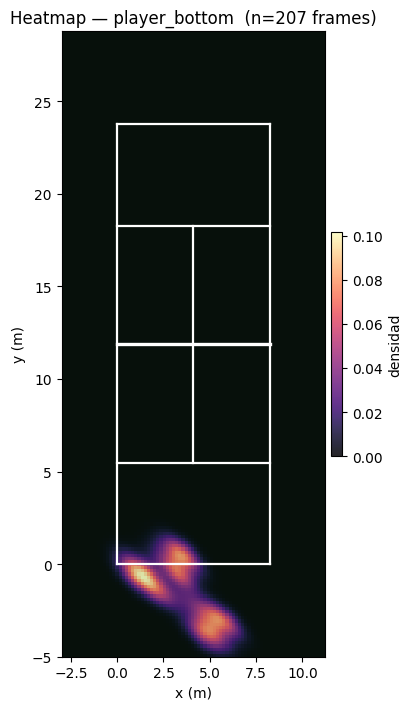

Guardado c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\heatmaps\player_2_heatmap.png


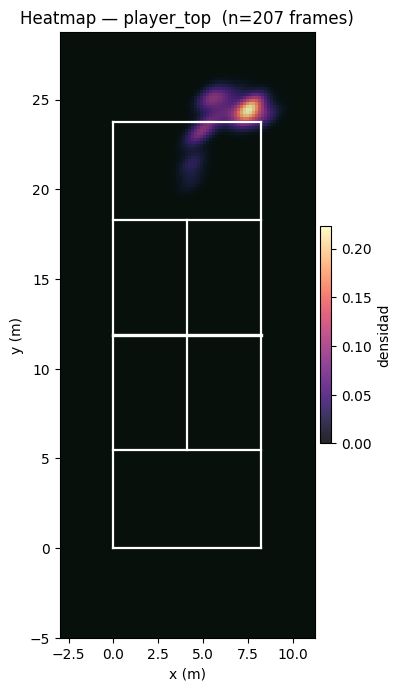

Guardado c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\heatmaps\player_1_heatmap.png


In [15]:
# Render + export de cada jugador (escalas independientes)
for pid in player_ids:
    out_path = PLAYER_OUT.get(pid, HEATMAPS_DIR / f"player_{pid}_heatmap.png")
    export_player_heatmap(pid, df_players, out_path)


## 4. Mapa de rebotes de pelota

Puntos de rebote (`is_bounce=1`) sobre la pista 2D y, encima, una KDE de la densidad de rebotes.

In [16]:
def bounce_map(df_ball, ax, cmap=BALL_CMAP, title="Rebotes de pelota"):
    valid = df_ball.dropna(subset=["ball_real_x", "ball_real_y"])
    bounces = valid[valid["is_bounce"] == 1]
    ax.set_facecolor("#2e6b3a")
    im = None
    if len(bounces) >= 2 and not np.allclose(bounces[["ball_real_x", "ball_real_y"]].std().to_numpy(), 0):
        xs, ys, XX, YY = make_grid()
        kde = gaussian_kde(np.vstack([bounces["ball_real_x"], bounces["ball_real_y"]]),
                            bw_method=KDE_BANDWIDTH)
        Z = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
        im = ax.imshow(
            Z, origin="lower",
            extent=[xs.min(), xs.max(), ys.min(), ys.max()],
            cmap=cmap, alpha=0.75, aspect="equal",
        )
    draw_court_2d(ax)
    ax.scatter(bounces["ball_real_x"], bounces["ball_real_y"],
               s=55, marker="X", color="cyan", edgecolors="white",
               linewidths=1.2, label=f"rebotes (n={len(bounces)})")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(title)
    return im


if df_ball is not None:
    fig, ax = plt.subplots(figsize=(_FIG_W, _FIG_H))
    im = bounce_map(df_ball, ax)
    if im is not None:
        cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        cbar.set_label("densidad de rebotes")
    plt.tight_layout()
    fig.savefig(BALL_OUT, dpi=DPI_EXPORT, bbox_inches="tight")
    plt.show()
    print(f"Guardado {BALL_OUT}")
else:
    print("Sección omitida: no hay ball_real_coords.csv.")


Sección omitida: no hay ball_real_coords.csv.


## 5. Vista combinada

Heatmaps de los dos jugadores y mapa de rebotes en una única figura.

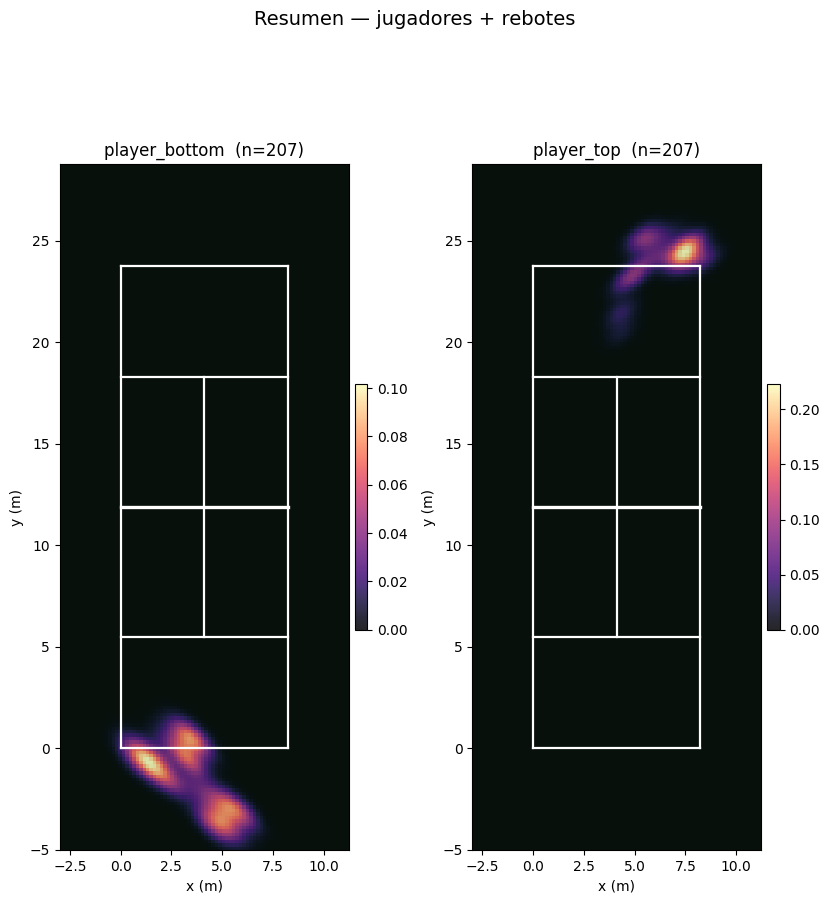

Guardado c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\heatmaps\combined_view.png


In [17]:
n_panels = len(player_ids) + (1 if df_ball is not None else 0)
fig, axes = plt.subplots(1, n_panels, figsize=(_FIG_W * n_panels, _FIG_H))
if n_panels == 1:
    axes = [axes]

for ax, pid in zip(axes[:len(player_ids)], player_ids):
    sub = df_players[df_players[id_col].astype(str) == str(pid)]
    im = player_heatmap(sub["real_x"].to_numpy(), sub["real_y"].to_numpy(),
                        ax, title=f"{pid}  (n={len(sub)})")
    if im is not None:
        fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

if df_ball is not None:
    im_b = bounce_map(df_ball, axes[-1])
    if im_b is not None:
        fig.colorbar(im_b, ax=axes[-1], fraction=0.04, pad=0.02)

fig.suptitle("Resumen — jugadores + rebotes", fontsize=14)
plt.tight_layout()
fig.savefig(COMBINED_OUT, dpi=DPI_EXPORT, bbox_inches="tight")
plt.show()
print(f"Guardado {COMBINED_OUT}")


## 6. Resumen de exportaciones

In [ ]:
for p in sorted(HEATMAPS_DIR.glob("*.png")):
    print(f"  {p}  ({p.stat().st_size/1024:.1f} KB)")

  c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\heatmaps\combined_view.png  (125.3 KB)
  c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\heatmaps\player_1_heatmap.png  (72.2 KB)
  c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\heatmaps\player_2_heatmap.png  (78.7 KB)
